# Visualize data — DIB 15272 / 15672, normal and PC

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import corner, h5py, os, glob, re, io, subprocess, tempfile
import emcee
from scipy.stats import gaussian_kde, ks_2samp
from scipy.ndimage import gaussian_filter
from scipy.interpolate import interp1d
from scipy.signal import fftconvolve
from IPython.display import display, Image
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

import sys
sys.path.insert(0, os.path.expanduser('~/DIB'))
from MCMC_convergence_tests import detect_multimodal, ks_stability_test, compute_rhat, format_diagnostics

# ── Matplotlib style ──────────────────────────────────────────────────────────
mpl.rcParams.update(mpl.rcParamsDefault)
plt.rcParams['figure.facecolor'] = 'white'
plt.rc('text', usetex=False)
plt.rc('font', family='serif', size=12)
plt.rc('axes', linewidth=1.5)
plt.rc('xtick', labelsize=11, direction='in', top=True)
plt.rc('ytick', labelsize=11, direction='in', right=True)
plt.rc('xtick.minor', visible=True)
plt.rc('ytick.minor', visible=True)
plt.rc('xtick.major', size=6, pad=4)
plt.rc('xtick.minor', size=3)
plt.rc('ytick.major', size=6)
plt.rc('ytick.minor', size=3)
plt.rc('legend', fontsize=10)
import datetime
import pandas as pd
from scipy.stats import chi2 as chi2_dist


Visualize in first row the direct profile, and in the second row the dP/dx_1 profile, with different error prescriptions

[DIB 15272] ✓ All 5 cropped wavelength arrays match (75 pixels each).


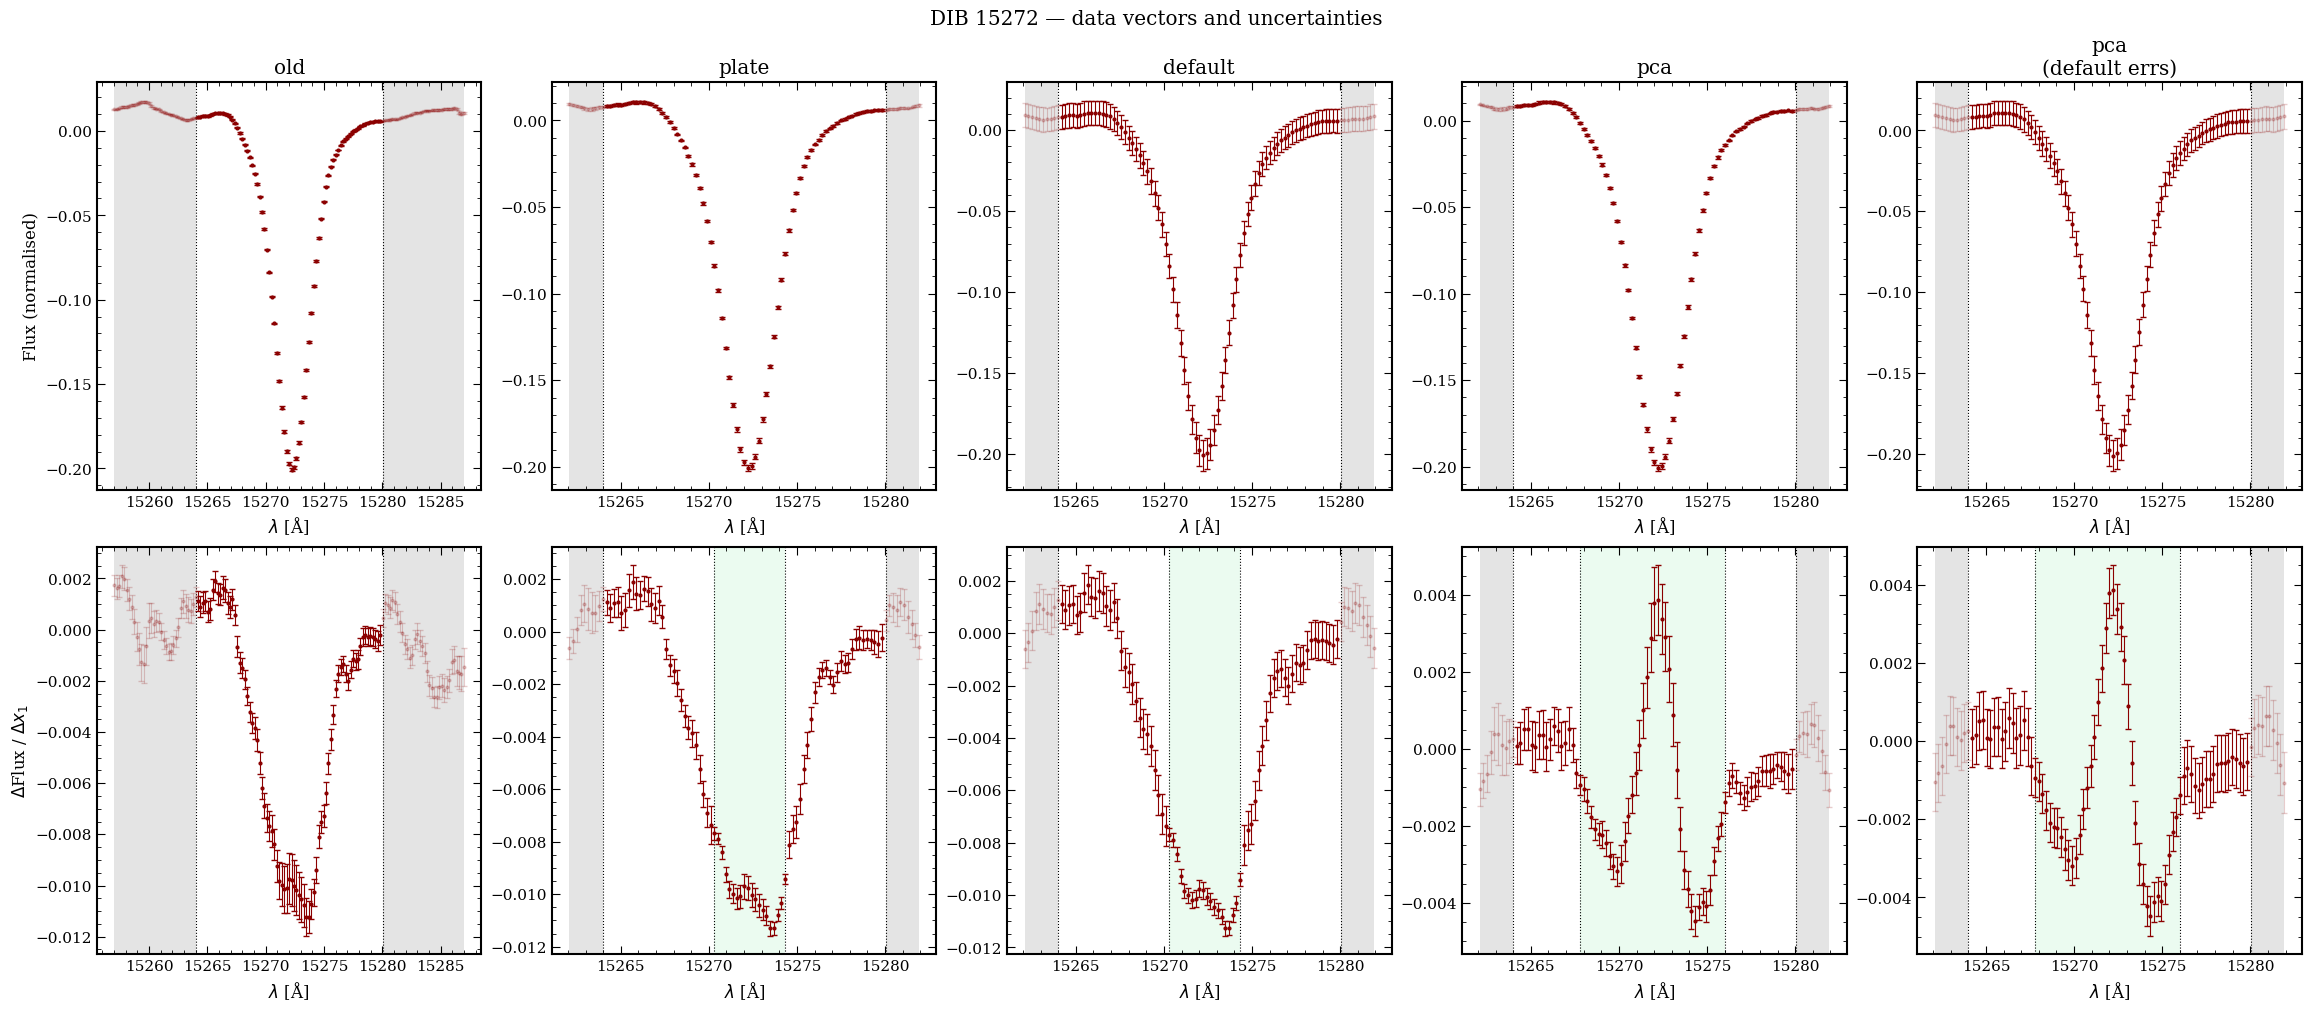

[DIB 15672] ✓ All 4 cropped wavelength arrays match (62 pixels each).


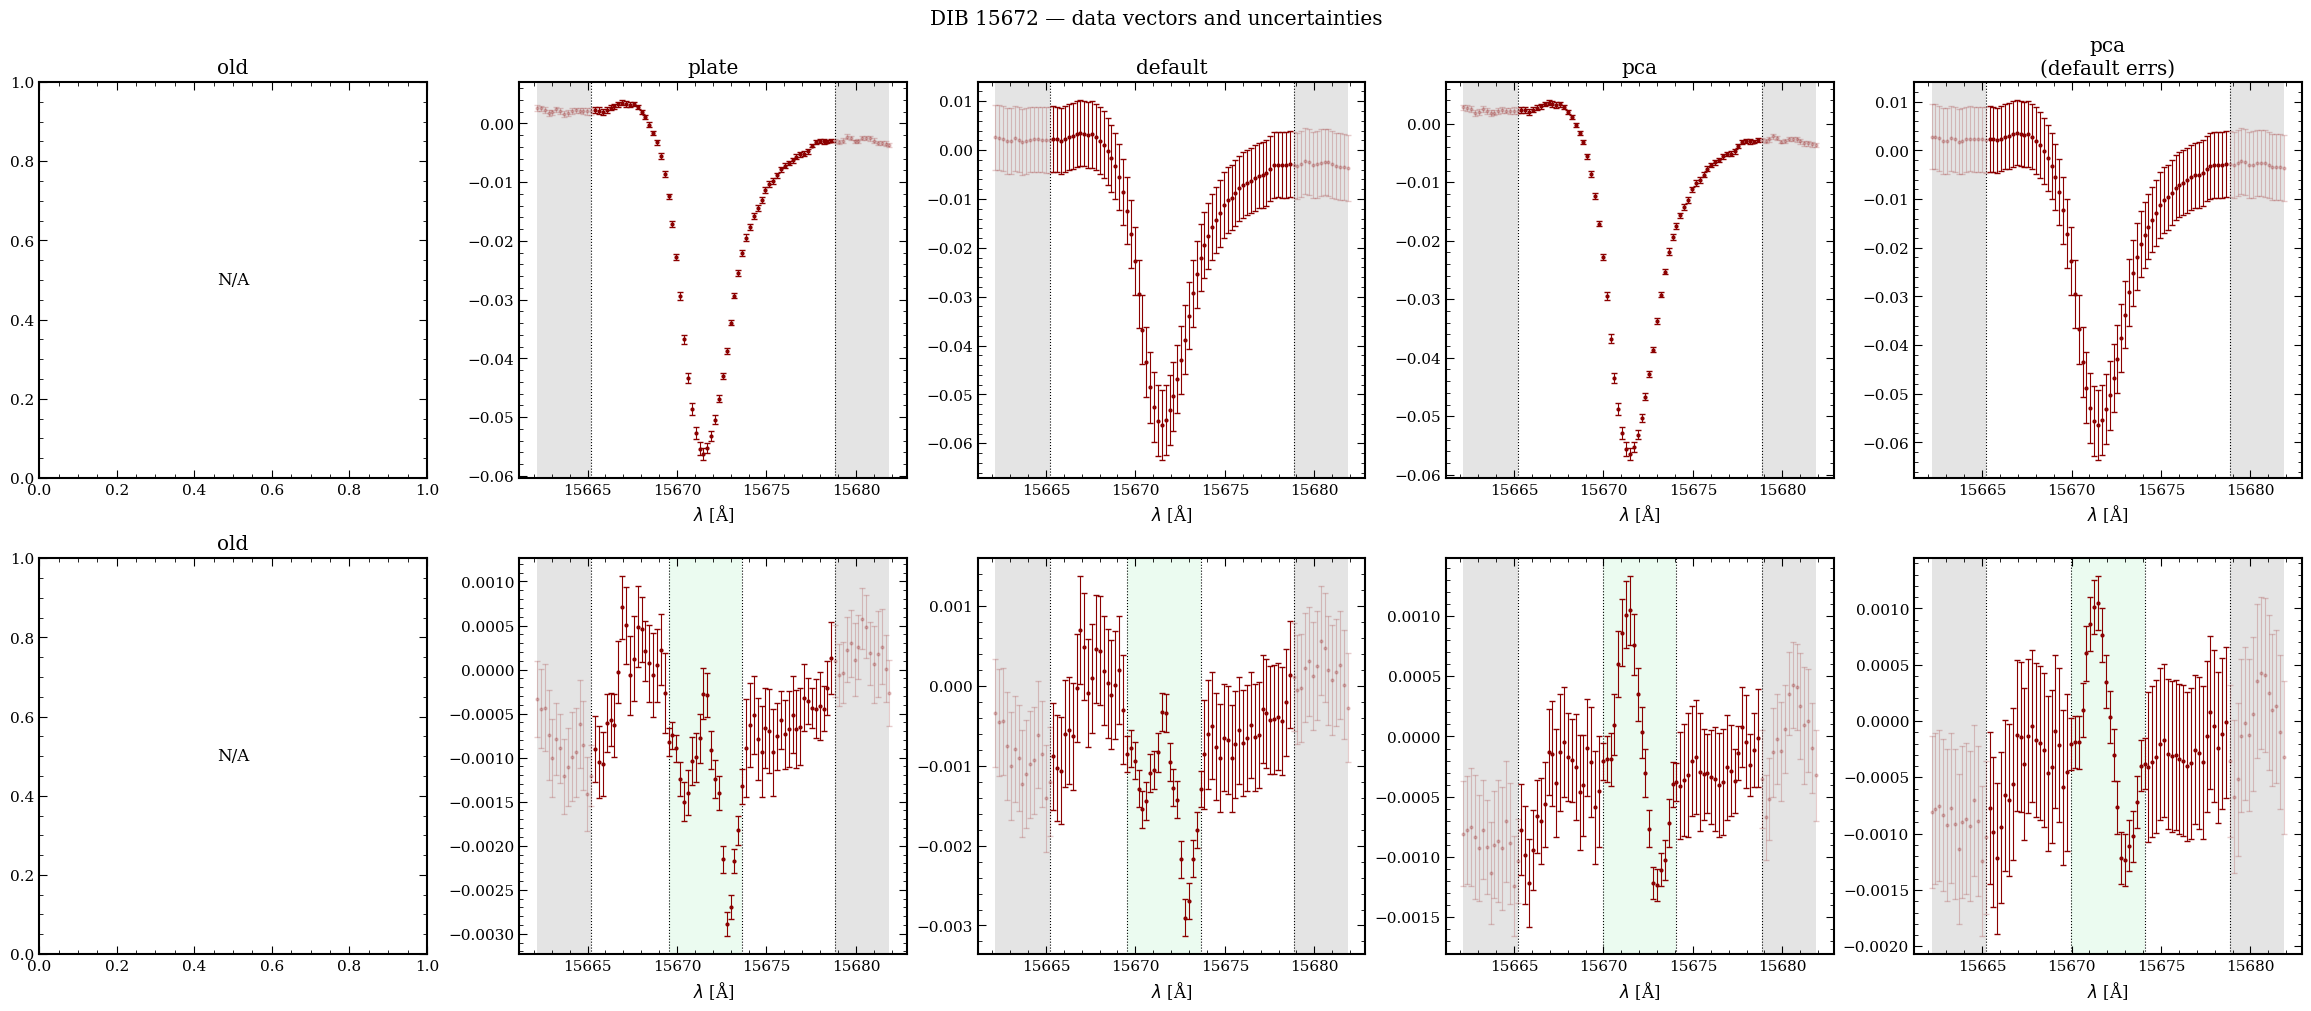

In [12]:

# ════════════════════════════════════════════════════════════════════════════
#  CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════
dib_bands    = ['15272', '15672']
which_errs   = ['old', 'plate', 'default', 'pca', 'pca_default']
fudge        = 1
balance_errs = False   # rescale spectrum errors to match relative dT error level
per_color    = False  # True → distinct colour per error model; False → all dark red

# Edge pixels to grey out per (err_model, dib_band) — mimics the crop used during fitting
crops = {
    'old':         {'15272': 34, '15672': 39},
    'plate':       {'15272': 10, '15672': 15},
    'default':     {'15272': 10, '15672': 15},
    'pca':         {'15272': 10, '15672': 15},
    'pca_default': {'15272': 10, '15672': 15}}

# Per-model emphasis of the dT centre (mimics --emphasize_dT_center).
# Keys: 'width'  — half-width in pixels (window = [ci+offset-width : ci+offset+width])
#       'factor' — divide dT errors inside the window by this factor
#       'offset' — shift the window centre from the array midpoint (pixels, can be negative)
# Set a model's value to None to disable for that model.
emphasize_dT_centers = {'15272': {
    'old':         None,
    'plate':       {'width': 10, 'factor': 3, 'offset': 2},
    'default':     {'width': 10, 'factor': 3, 'offset': 2},
    'pca':         {'width': 20, 'factor': 2, 'offset': 0},
    'pca_default': {'width': 20, 'factor': 2, 'offset': 0}},
                       '15672': {
    'old':         None,
    'plate':       {'width': 10, 'factor': 2, 'offset': -2},
    'default':     {'width': 10, 'factor': 2, 'offset': -2},
    'pca':         {'width': 10, 'factor': 2, 'offset': 0},
    'pca_default': {'width': 10, 'factor': 2, 'offset': 0}}}                       

DARK_RED      = '#8B0000'
ERR_COLORS    = {
    'old':         '#4C72B0',
    'plate':       '#DD8452',
    'default':     '#55A868',
    'pca':         '#C44E52',
    'pca_default': '#9467BD',
}
CROP_ALPHA    = 0.20
CROP_BG_ALPHA = 0.30
CROP_BG_COL   = '0.65'
EMPH_BG_COL   = '#00CC44'
EMPH_BG_ALPHA = 0.08

ROW_YLABELS = ['Flux (normalised)', r'$\Delta$Flux / $\Delta x_1$']

# ════════════════════════════════════════════════════════════════════════════
#  MAIN LOOP
# ════════════════════════════════════════════════════════════════════════════
for dib_band in dib_bands:

    fig, axes = plt.subplots(2, 5, figsize=(23, 10), constrained_layout=True)
    fig.suptitle(f'DIB {dib_band} — data vectors and uncertainties')

    wav_cropped_by_model = {}

    for col_idx, err_model in enumerate(which_errs):
        col = ERR_COLORS[err_model] if per_color else DARK_RED
        c   = crops[err_model][dib_band]

        # ── Load data ──────────────────────────────────────────────────────
        try:
            if err_model == 'old':
                if dib_band == '15672':
                    for row in range(2):
                        axes[row, col_idx].text(0.5, 0.5, 'N/A', ha='center', va='center',
                                                transform=axes[row, col_idx].transAxes)
                        axes[row, col_idx].set_title('old')
                    continue
                with h5py.File(os.path.expanduser('~/DIB/all_errs/jackknife_dib.h5'), 'r') as ef:
                    flux    = ef['mean'][0, :, 0]
                    flux_dT = ef['mean'][0, :, 1]
                    err     = fudge * np.sqrt(ef['var'][:, 0])
                    err_dT  = fudge * np.sqrt(ef['var'][:, 1])
                pca_old = pd.read_csv(os.path.expanduser('~/DIB/all_errs/pca_version.txt'),
                                      sep=r'\s+',
                                      names=['wavelength', 'PC1_1', 'PC1_2', 'PC2_1', 'PC2_2'])
                wav = pca_old['wavelength'].values

            elif err_model == 'plate':
                with h5py.File(os.path.expanduser(f'~/DIB/all_errs/jackknife_plates_dib_{dib_band}.h5'), 'r') as ef:
                    flux    = ef['mean'][:, 0]
                    flux_dT = ef['mean'][:, 1]
                    err     = fudge * np.sqrt(ef['var'][:, 0])
                    err_dT  = fudge * np.sqrt(ef['var'][:, 1])
                with h5py.File(os.path.expanduser(f'~/DIB/all_errs/res_dib_{dib_band}.h5'), 'r') as df:
                    wav = df['wav'][:]

            elif err_model == 'default':
                with h5py.File(os.path.expanduser(f'~/DIB/all_errs/res_dib_{dib_band}.h5'), 'r') as df:
                    wav     = df['wav'][:]
                    flux    = df['mean'][:, 0]
                    flux_dT = df['mean'][:, 1]
                    err     = fudge * np.sqrt(df['var'][:, 0])
                    err_dT  = fudge * np.sqrt(df['var'][:, 1])

            elif err_model == 'pca':
                pca_meas = pd.read_csv(
                    os.path.expanduser(f'~/DIB/all_errs/pca_version_{dib_band}_narrow.txt'),
                    sep=r'\s+', names=['wavelength', 'PC1_1', 'PC1_2', 'PC2_1', 'PC2_2'])
                wav     = pca_meas['wavelength'].values
                flux    = pca_meas['PC1_1'].values
                flux_dT = pca_meas['PC2_2'].values
                with h5py.File(os.path.expanduser(f'~/DIB/all_errs/jackknife_plates_dib_{dib_band}.h5'), 'r') as ef:
                    err    = fudge * np.sqrt(ef['var'][:len(wav), 0])
                    err_dT = fudge * np.sqrt(ef['var'][:len(wav), 1])

            elif err_model == 'pca_default':
                pca_meas = pd.read_csv(
                    os.path.expanduser(f'~/DIB/all_errs/pca_version_{dib_band}_narrow.txt'),
                    sep=r'\s+', names=['wavelength', 'PC1_1', 'PC1_2', 'PC2_1', 'PC2_2'])
                wav     = pca_meas['wavelength'].values
                flux    = pca_meas['PC1_1'].values
                flux_dT = pca_meas['PC2_2'].values
                with h5py.File(os.path.expanduser(f'~/DIB/all_errs/res_dib_{dib_band}.h5'), 'r') as df:
                    err    = fudge * np.sqrt(df['var'][:len(wav), 0])
                    err_dT = fudge * np.sqrt(df['var'][:len(wav), 1])

        except Exception as ex:
            for row in range(2):
                axes[row, col_idx].text(0.5, 0.5, f'Load error:\n{ex}',
                                        ha='center', va='center',
                                        transform=axes[row, col_idx].transAxes)
                axes[row, col_idx].set_title(err_model)
            continue

        # ── Store cropped wavelength for validation ────────────────────────
        wav_cropped_by_model[err_model] = wav[c:-c] if c > 0 else wav.copy()

        # ── Emphasize dT centre ────────────────────────────────────────────
        err_dT_plot = err_dT.copy()
        emphasize_dT_center = emphasize_dT_centers[dib_band]
        emph_cfg = emphasize_dT_center.get(err_model)
        if emph_cfg is not None:
            emph_w   = int(emph_cfg['width'])
            emph_fac = emph_cfg['factor']
            emph_off = int(emph_cfg.get('offset', 0))
            ci       = len(err_dT_plot) // 2 + emph_off
            lo_idx   = max(ci - emph_w, 0)
            hi_idx   = min(ci + emph_w, len(err_dT_plot))
            err_dT_plot[lo_idx:hi_idx] /= emph_fac
            # wavelength borders for visual markers
            emph_wav_lo = wav[lo_idx]
            emph_wav_hi = wav[min(hi_idx - 1, len(wav) - 1)]
            
        # ── Balance errors ─────────────────────────────────────────────────
        if balance_errs:
            peak_range   = np.abs(np.nanmax(flux)    - np.nanmin(flux))
            dT_range     = np.abs(np.nanmax(flux_dT) - np.nanmin(flux_dT))
            peak_rel_err = np.nanmedian(err)    / peak_range
            dT_rel_err   = np.nanmedian(err_dT) / dT_range
            err = err * (dT_rel_err / peak_rel_err)

        # ── Build crop mask ────────────────────────────────────────────────
        mask_crop = np.zeros(len(wav), dtype=bool)
        if c > 0:
            mask_crop[:c]  = True
            mask_crop[-c:] = True
        mask_keep = ~mask_crop

        # ── Plot both rows ─────────────────────────────────────────────────
        for row, (data, noise) in enumerate([(flux, err), (flux_dT, err_dT_plot)]):
            ax = axes[row, col_idx]

            # Grey crop zones + dotted vlines at inner borders
            if c > 0:
                ax.axvspan(wav[0],   wav[c - 1], color=CROP_BG_COL, alpha=CROP_BG_ALPHA, lw=0)
                ax.axvspan(wav[-c],  wav[-1],    color=CROP_BG_COL, alpha=CROP_BG_ALPHA, lw=0)
                ax.axvline(wav[c - 1], color='k', lw=0.8, ls=':')
                ax.axvline(wav[-c],    color='k', lw=0.8, ls=':')

            # Green emphasis zone on dT row only
            if row == 1 and emph_cfg is not None:
                ax.axvspan(emph_wav_lo, emph_wav_hi, color=EMPH_BG_COL, alpha=EMPH_BG_ALPHA, lw=0)
                ax.axvline(emph_wav_lo, color='k', lw=0.8, ls=':')
                ax.axvline(emph_wav_hi, color='k', lw=0.8, ls=':')

            ax.errorbar(wav[mask_keep], data[mask_keep], yerr=noise[mask_keep],
                        fmt='o', color=col, ecolor=col,
                        markersize=2, elinewidth=0.8, capsize=2)
            if mask_crop.any():
                ax.errorbar(wav[mask_crop], data[mask_crop], yerr=noise[mask_crop],
                            fmt='o', color=col, ecolor=col,
                            markersize=2, elinewidth=0.8, capsize=2, alpha=CROP_ALPHA)

            if row == 0:
                ax.set_title('pca\n(default errs)' if err_model == 'pca_default' else err_model)
            if col_idx == 0:
                ax.set_ylabel(ROW_YLABELS[row])
            ax.set_xlabel(r'$\lambda$ [Å]')

    # ── Wavelength validation ──────────────────────────────────────────────
    if wav_cropped_by_model:
        models_present = list(wav_cropped_by_model.keys())
        ref_model = models_present[0]
        ref_wav   = wav_cropped_by_model[ref_model]
        all_ok    = True
        for m in models_present[1:]:
            w = wav_cropped_by_model[m]
            if len(w) != len(ref_wav):
                print(f"[DIB {dib_band}] WARNING: '{m}' cropped wav length {len(w)} "
                      f"≠ '{ref_model}' length {len(ref_wav)}")
                all_ok = False
            elif not np.allclose(w, ref_wav):
                diffs = np.where(~np.isclose(w, ref_wav))[0]
                print(f"[DIB {dib_band}] WARNING: '{m}' cropped wav differs from '{ref_model}' "
                      f"at {len(diffs)} position(s) — "
                      f"first mismatch idx {diffs[0]}: {w[diffs[0]]:.4f} vs {ref_wav[diffs[0]]:.4f} Å")
                all_ok = False
        if all_ok:
            print(f"[DIB {dib_band}] ✓ All {len(models_present)} cropped wavelength arrays "
                  f"match ({len(ref_wav)} pixels each).")

    plt.show()
